# T03 - Griegas y aproximación del valor de una opción

##### Maria Fernanda Gómez Flores
##### 21 de Septiembre 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Parte 1. Observación de las opciones

Primero voy a comparar las 3 opciones viendo sus griegas para ver a que cambios responde mas cada una

In [2]:
opciones = pd.DataFrame({
    "Opcion": ["A", "B", "C"],
    "K": [90, 100, 120],
    "T": [1/12, 3/12, 1],
    "Prima": [12, 8, 5],
    "Delta": [0.85, 0.50, 0.20],
    "Vega": [0.05, 0.25, 0.40],
    "Theta": [-0.10, -0.03, -0.01]
})

opciones

,Opcion,K,T,Prima,Delta,Vega,Theta
0,A,90,0.083333,12,0.85,0.05,-0.10
1,B,100,0.250000,8,0.50,0.25,-0.03
2,C,120,1.000000,5,0.20,0.40,-0.01


### 1. ¿Cuál opción parece más sensible a cambios en el precio de la acción?

La opcion A porque tiene el Delta mas alto de 0.85 entonces es la que mas cambia cuando cambia el precio de la accion

### 2. ¿Cuál opción parece más sensible a cambios en volatilidad?

La opcion C porque tiene el Vega mas alto de 0.40 entonces es la que mas reacciona cuando cambia la volatilidad

### 3. ¿Cuál opción parece deteriorarse más rápidamente con el paso del tiempo?

La opcion A porque su Theta es -0.10 y es el mas negativo de las tres entonces pierde valor mas rapido conforme pasa el tiempo

### 4. ¿Cuál opción parece tener el comportamiento más parecido al de la acción?

La opcion A porque su Delta es 0.85 y es el que esta mas cerca de 1 entonces su precio se mueve mas parecido al de la accion

### 5. ¿Cuál opción parece depender más de que ocurra un evento importante en el futuro?

La opcion C porque tiene el Vega mas alto y tambien es la que tiene mas tiempo al vencimiento entonces depende mas de que pase algo que aumente la volatilidad

## Parte 2. Escenarios

### Escenario A

La accion sube gradualmente durante los proximos meses y la volatilidad no cambia

Compraria la opcion B porque tiene un Delta de 0.50 y todavia tiene 3 meses para que la subida de la accion le ayude. Evitaria la C porque su Delta es de solo 0.20 y aparte su Vega alto no ayuda mucho si la volatilidad no cambia

### Escenario B

En dos semanas la empresa anuncia un producto nuevo y se espera un movimiento brusco pero no sabemos hacia donde

Compraria la opcion C porque tiene el Vega mas alto de 0.40 entonces si aumenta la incertidumbre su valor puede aumentar mas. Evitaria la A porque su Vega es muy bajo y su Theta es el mas negativo

### Escenario C

La accion se mantiene muy estable

Compraria la opcion C porque tiene el Theta menos negativo de -0.01 entonces es la que pierde menos valor por el paso del tiempo. Evitaria la A porque tiene un Theta de -0.10 y es la que se deteriora mas rapido

### Escenario D

Se espera una caida importante en el precio de la accion

Realmente las tres son calls entonces ninguna seria buena para una caida. Pero si tuviera que escoger compraria la C porque tiene el Delta mas bajo de 0.20 entonces le afecta menos la caida. Evitaria la A porque tiene el Delta mas alto de 0.85

### Escenario E

El mercado esta subestimando la incertidumbre futura

Compraria la opcion C porque tiene el Vega mas alto de 0.40 entonces se beneficia mas si despues aumenta la volatilidad. Evitaria la A porque tiene el Vega mas bajo

## Parte 3. Aproximación con Greeks

Ahora voy a usar las griegas que nos dan al inicio para ir aproximando el valor de la opcion cada mes

La formula que voy a usar es:

V nuevo = V anterior + Delta(dS) + 1/2 Gamma(dS)^2 + Vega(dSigma) + Theta(dt)

Voy a sacar dS y dSigma comparando cada mes con el mes anterior

In [3]:
r = 0.05
K = 100

V0 = 6.8887
Delta = 0.5977
Gamma = 0.02736
Vega = 0.2814
Theta = -8.116

dt = 1/12

In [4]:
datos = pd.DataFrame({
    "Mes": ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"],
    "Precio": [100, 102, 101, 105, 103, 110],
    "Volatilidad": [20, 25, 30, 28, 22, 20]
})

datos

,Mes,Precio,Volatilidad
0,Mayo,100,20
1,Junio,102,25
2,Julio,101,30
3,Agosto,105,28
4,Septiembre,103,22
5,Octubre,110,20


In [5]:
datos["dS"] = datos["Precio"].diff()
datos["dSigma"] = datos["Volatilidad"].diff()

datos

,Mes,Precio,Volatilidad,dS,dSigma
0,Mayo,100,20,NaN,NaN
1,Junio,102,25,2.0,5.0
2,Julio,101,30,-1.0,5.0
3,Agosto,105,28,4.0,-2.0
4,Septiembre,103,22,-2.0,-6.0
5,Octubre,110,20,7.0,-2.0


Aqui por ejemplo de mayo a junio el precio cambia de 100 a 102 entonces dS es 2 y la volatilidad cambia de 20 a 25 entonces dSigma es 5

In [6]:
valores_greeks = [V0]

for i in range(1, len(datos)):

    dS = datos.loc[i, "dS"]
    dSigma = datos.loc[i, "dSigma"]

    cambio = Delta*dS + 0.5*Gamma*dS**2 + Vega*dSigma + Theta*dt

    valor_nuevo = valores_greeks[-1] + cambio

    valores_greeks.append(valor_nuevo)

datos["Valor aproximado (Greeks)"] = valores_greeks

datos.round(4)

,Mes,Precio,Volatilidad,dS,dSigma,Valor aproximado (Greeks)
0,Mayo,100,20,NaN,NaN,6.8887
1,Junio,102,25,2.0,5.0,8.8695
2,Julio,101,30,-1.0,5.0,9.0161
3,Agosto,105,28,4.0,-2.0,10.3867
4,Septiembre,103,22,-2.0,-6.0,6.8813
5,Octubre,110,20,7.0,-2.0,10.4964


Lo que estoy haciendo es empezar con el valor de mayo que ya nos lo dan y despues cada mes le sumo el cambio aproximado usando las griegas iniciales

## Black-Scholes

Ahora voy a calcular el precio de la call con Black-Scholes para cada mes usando el precio la volatilidad y el tiempo que queda

In [7]:
datos["Tiempo restante"] = [6/12, 5/12, 4/12, 3/12, 2/12, 1/12]

precios_bs = []

for i in range(len(datos)):

    S = datos.loc[i, "Precio"]
    V = datos.loc[i, "Volatilidad"] / 100
    T = datos.loc[i, "Tiempo restante"]

    d1 = (np.log(S/K) + (r + (1/2)*V**2)*T) / (V*np.sqrt(T))
    d2 = d1 - V*np.sqrt(T)

    C = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    precios_bs.append(C)

datos["Black-Scholes"] = precios_bs

datos[["Mes", "Precio", "Volatilidad", "Tiempo restante", "Black-Scholes"]].round(4)

,Mes,Precio,Volatilidad,Tiempo restante,Black-Scholes
0,Mayo,100,20,0.5000,6.8887
1,Junio,102,25,0.4167,8.6621
2,Julio,101,30,0.3333,8.2860
3,Agosto,105,28,0.2500,9.3418
4,Septiembre,103,22,0.1667,5.8530
5,Octubre,110,20,0.0833,10.5202


## Simulación de 10,000 escenarios

Tambien voy a simular 10,000 precios para cada mes igual que en los ejercicios anteriores de Monte Carlo

In [8]:
M = 10000

precios_mc = []

np.random.seed(32)

for i in range(len(datos)):

    S0 = datos.loc[i, "Precio"]
    V = datos.loc[i, "Volatilidad"] / 100
    T = datos.loc[i, "Tiempo restante"]

    Z = np.random.normal(0, 1, size=M)

    ST = S0*np.exp((r-0.5*V**2)*T + V*np.sqrt(T)*Z)

    ganancia_call = np.maximum(ST-K, 0)

    precio_call_mc = np.exp(-r*T)*ganancia_call.mean()

    precios_mc.append(precio_call_mc)

datos["Monte Carlo"] = precios_mc

datos[["Mes", "Black-Scholes", "Monte Carlo"]].round(4)

,Mes,Black-Scholes,Monte Carlo
0,Mayo,6.8887,7.0126
1,Junio,8.6621,8.9652
2,Julio,8.2860,8.1875
3,Agosto,9.3418,9.3221
4,Septiembre,5.8530,5.9230
5,Octubre,10.5202,10.5894


Los resultados de Monte Carlo no tienen que salir exactamente iguales a Black-Scholes porque estamos usando numeros aleatorios pero deberian de quedar cercanos

## Comparación Greeks vs Black-Scholes

In [9]:
datos["Error Absoluto"] = np.abs(datos["Valor aproximado (Greeks)"] - datos["Black-Scholes"])

comparacion = datos[[
    "Mes",
    "Valor aproximado (Greeks)",
    "Black-Scholes",
    "Error Absoluto"
]]

comparacion.round(4)

,Mes,Valor aproximado (Greeks),Black-Scholes,Error Absoluto
0,Mayo,6.8887,6.8887,0.0000
1,Junio,8.8695,8.6621,0.2074
2,Julio,9.0161,8.2860,0.7301
3,Agosto,10.3867,9.3418,1.0449
4,Septiembre,6.8813,5.8530,1.0283
5,Octubre,10.4964,10.5202,0.0239


## Gráfica

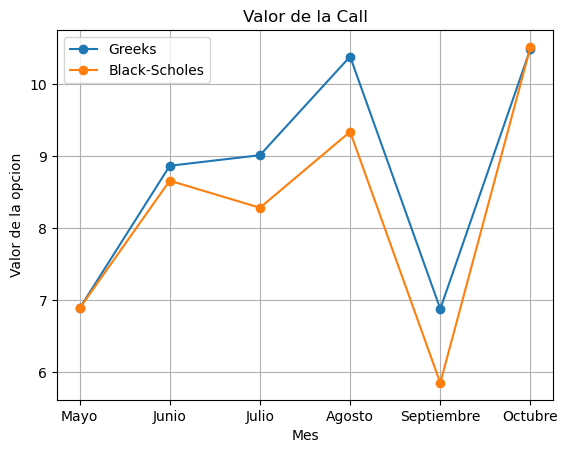

In [10]:
plt.plot(datos["Mes"], datos["Valor aproximado (Greeks)"], marker="o", label="Greeks")
plt.plot(datos["Mes"], datos["Black-Scholes"], marker="o", label="Black-Scholes")

plt.xlabel("Mes")
plt.ylabel("Valor de la opcion")
plt.title("Valor de la Call")
plt.legend()
plt.grid()

plt.show()

## Preguntas finales

### 1. ¿Las Greeks iniciales describen con precisión toda la trayectoria?

No completamente. Al inicio si se acercan pero conforme van cambiando el precio la volatilidad y el tiempo tambien deberian de cambiar las griegas. Aqui estamos usando las mismas de mayo para todos los meses

### 2. ¿En qué mes aparece el mayor error?

El mayor error aparece en agosto. El valor con Greeks es aproximadamente 10.3867 y con Black-Scholes es 9.3418 entonces el error es de aproximadamente 1.0449

### 3. ¿Qué factor parece contribuir más al error?

Creo que principalmente que estamos dejando las griegas fijas aunque el precio la volatilidad y el tiempo van cambiando. Por ejemplo en agosto el precio cambia bastante y aun asi seguimos usando el mismo Delta y Gamma de mayo

### 4. ¿Por qué las Greeks funcionan mejor para movimientos pequeños que para movimientos grandes?

Porque las griegas nos dan una aproximacion alrededor del punto donde fueron calculadas. Si el cambio es pequeño seguimos cerca de ese punto pero si el precio o la volatilidad cambian mucho la aproximacion ya se empieza a alejar

### 5. Si la trayectoria fuera mucho más volátil ¿esperarías errores menores?

No esperaria errores menores mas bien podrian aumentar porque tendriamos cambios mas grandes en el precio y en la volatilidad y las griegas iniciales cada vez representarian menos lo que esta pasando despues

## Conclusión

Las griegas sirven para ver rapido como puede cambiar el precio de una opcion cuando cambia el precio de la accion la volatilidad o el tiempo. Pero no sirven para calcular exactamente toda una trayectoria si dejamos las mismas griegas desde el inicio porque estas tambien van cambiando. En este ejercicio se ve que para cambios pequeños la aproximacion queda bastante cerca pero en algunos meses el error aumenta. Por eso para calcular el valor mas exacto conviene volver a usar Black-Scholes con los datos de cada mes